In [1]:
import pandas as pd
import os
import json
from PIL import Image

IMG_DIR = "/kaggle/input/datasets/dipsy32/sample-dataset/sample_35k/images"
ANNO_DIR = "/kaggle/input/datasets/dipsy32/sample-dataset/sample_35k/annos"

train_df = pd.read_csv("/kaggle/input/datasets/dipsy32/training-datasets/train_annotations.csv")
val_df = pd.read_csv("/kaggle/input/datasets/dipsy32/training-datasets/val_annotations.csv")
test_df = pd.read_csv("/kaggle/input/datasets/dipsy32/training-datasets/test_annotations.csv")

print(len(train_df), len(val_df), len(test_df))

39241 8386 8453


In [2]:
classes = [
    "long sleeve top",
    "short sleeve top",
    "shorts",
    "skirt",
    "trousers"
]

class_to_id = {c:i for i,c in enumerate(classes)}

In [3]:
os.makedirs("/kaggle/working/yolo/seg/train/images", exist_ok=True)
os.makedirs("/kaggle/working/yolo/seg/train/labels", exist_ok=True)

os.makedirs("/kaggle/working/yolo/seg/val/images", exist_ok=True)
os.makedirs("/kaggle/working/yolo/seg/val/labels", exist_ok=True)

In [4]:
import os
import numpy as np

def compute_class_weights(label_dir, num_classes=5):
    """
    Scan all YOLO label .txt files in label_dir and compute
    inverse-frequency class weights.

    Returns
    -------
    weights : np.ndarray, shape (num_classes,)
        weights[i] = total_instances / (num_classes * count_i)
        Rare classes get higher weight, frequent classes lower.
    counts  : np.ndarray  -- raw instance counts per class
    """
    counts = np.zeros(num_classes, dtype=np.float64)

    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                cls_id = int(line.split()[0])
                if 0 <= cls_id < num_classes:
                    counts[cls_id] += 1

    total = counts.sum()
    if total == 0:
        raise ValueError(f"No label files found in '{label_dir}'. Run process_split / process_segmentation first.")
    # Guard against zero-count classes: assign weight = max_weight
    safe_counts = np.where(counts > 0, counts, 1.0)  # avoid div-by-zero in np.divide
    weights = np.where(counts > 0,
                       total / (num_classes * safe_counts),
                       total / num_classes)

    # Normalize so mean weight == 1  (keeps loss scale stable)
    weights = weights / weights.mean()
    return weights, counts


In [5]:
from torch.utils.data import WeightedRandomSampler

def make_weighted_sampler(label_dir, num_classes=5):
    """
    Build a WeightedRandomSampler that over-samples images containing
    rare classes and under-samples images containing frequent ones.

    Each image's weight = max inverse-frequency weight across all classes
    present in that image — so an image containing a rare class is drawn
    more often regardless of how many common-class instances it also has.
    """
    label_files = sorted(
        f for f in os.listdir(label_dir) if f.endswith(".txt")
    )

    if not label_files:
        raise ValueError(f"No label files found in '{label_dir}'")

    # Compute per-class inverse-frequency weights from the full set
    _, counts = compute_class_weights(label_dir, num_classes)
    total = counts.sum()
    safe  = np.where(counts > 0, counts, 1.0)
    inv_freq = np.where(counts > 0, total / (num_classes * safe), total / num_classes)
    inv_freq = inv_freq / inv_freq.mean()   # normalize so mean = 1

    sample_weights = []
    for fname in label_files:
        with open(os.path.join(label_dir, fname)) as f:
            ids = [int(l.split()[0]) for l in f if l.strip()]
        if ids:
            present_ids = [i for i in ids if 0 <= i < num_classes]
            # Weight = max inv_freq of all classes present in this image
            w = max(inv_freq[i] for i in present_ids) if present_ids else 1.0
        else:
            w = 1.0
        sample_weights.append(w)

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )


In [6]:
seg_yaml = """
path: /kaggle/working/yolo/seg

train: train/images
val: val/images

nc: 5

names:
  0: long sleeve top
  1: short sleeve top
  2: shorts
  3: skirt
  4: trousers
"""

with open("/kaggle/working/yolo/seg_data.yaml", "w") as f:
    f.write(seg_yaml)

print("seg_data.yaml written.")


seg_data.yaml written.


In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO

# yolov8n-seg.pt = pretrained COCO weights → true transfer learning
# yolov8n-seg.yaml = random weights only → training from scratch
model_seg = YOLO("yolov8n-seg.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
import os
import shutil
import numpy as np
from tqdm import tqdm

def process_segmentation(df, split):

    for img_name in tqdm(df["image"].unique()):

        img_path = os.path.join(IMG_DIR, img_name)
        anno_path = os.path.join(ANNO_DIR, img_name.replace(".jpg",".json"))

        if not os.path.exists(anno_path):
            continue

        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path)
        W, H = img.size

        with open(anno_path) as f:
            data = json.load(f)

        labels = []

        for item in data.values():

            if not isinstance(item, dict):
                continue

            cat = item.get("category_name")
            if cat not in class_to_id:
                continue

            cls_id = class_to_id[cat]

            segmentations = item.get("segmentation")

            if segmentations is None:
                continue

            # segmentation can have multiple polygons
            for seg in segmentations:

                if len(seg) < 6:
                    continue

                coords = np.array(seg, dtype=np.float32).reshape(-1, 2)

                # normalize
                coords[:, 0] /= W
                coords[:, 1] /= H

                coords = coords.flatten()

                line = f"{cls_id} " + " ".join(map(str, coords))
                labels.append(line)

        if len(labels) == 0:
            continue

        label_path = f"/kaggle/working/yolo/seg/{split}/labels/{img_name.replace('.jpg','.txt')}"

        with open(label_path, "w") as f:
            f.write("\n".join(labels))

        shutil.copy(img_path, f"/kaggle/working/yolo/seg/{split}/images/{img_name}")


In [10]:
process_segmentation(train_df, "train")
process_segmentation(val_df, "val")

100%|██████████| 5250/5250 [02:36<00:00, 33.61it/s]


In [11]:
seg_weights, seg_counts = compute_class_weights(
    "/kaggle/working/yolo/seg/train/labels", num_classes=5
)

print("Segmentation — train set class distribution")
print("=" * 52)
for i, cls in enumerate(classes):
    print(f"  {cls:20s} | count: {int(seg_counts[i]):6d} | weight: {seg_weights[i]:.4f}")
print(f"  {'Total':20s} | count: {int(seg_counts.sum()):6d}")


Segmentation — train set class distribution
  long sleeve top      | count:  24859 | weight: 0.5709
  short sleeve top     | count:  32119 | weight: 0.4419
  shorts               | count:  17669 | weight: 0.8033
  skirt                | count:   5366 | weight: 2.6450
  trousers             | count:  26338 | weight: 0.5389
  Total                | count: 106351


In [12]:
import ultralytics.data.build as _build_mod
import torch.utils.data as tud

# Keep reference to original — needed to restore before re-patching in stage 2
_orig_build_dataloader = _build_mod.build_dataloader

def patch_dataloader_with_sampler(label_dir, num_classes=5):
    """
    Monkey-patch Ultralytics build_dataloader to inject WeightedRandomSampler
    for the training split only. Val/test keep uniform sampling.
    Must be called BEFORE model.train().
    """
    sampler = make_weighted_sampler(label_dir, num_classes)

    def _patched(dataset, batch, workers, shuffle=True, rank=-1):
        if not shuffle:
            return _orig_build_dataloader(dataset, batch, workers, shuffle=False, rank=rank)
        loader = _orig_build_dataloader(dataset, batch, workers, shuffle=False, rank=rank)
        return tud.DataLoader(
            loader.dataset,
            batch_size=loader.batch_size,
            sampler=sampler,
            num_workers=loader.num_workers,
            pin_memory=getattr(loader, 'pin_memory', True),
            collate_fn=loader.collate_fn,
            drop_last=getattr(loader, 'drop_last', False),
        )

    _build_mod.build_dataloader = _patched
    print(f"Dataloader patched — WeightedRandomSampler active for training")
    print(f"  {len(sampler.weights)} images, replacement=True")

patch_dataloader_with_sampler("/kaggle/working/yolo/seg/train/labels", num_classes=5)


Dataloader patched — WeightedRandomSampler active for training
  24500 images, replacement=True


In [13]:
# ── Stage 1: freeze backbone (first 10 layers), train heads only ──────────────
model_seg.train(
    data="/kaggle/working/yolo/seg_data.yaml",
    epochs=5,
    imgsz=640,
    batch=16,
    lr0=0.001,
    freeze=5,
    optimizer="auto",
    patience=10,
    project="/kaggle/working/yolo_tl",
    name="stage1_seg"
)

# Load best checkpoint from stage 1 for full fine-tuning
model_seg = YOLO("/kaggle/working/yolo_tl/stage1_seg/weights/best.pt")

# ── Re-apply dataloader patch for stage 2 ─────────────────────────────────────
# New YOLO object created — patch doesn't persist. Restore original first
# to avoid stacking two patches, then re-patch.
_build_mod.build_dataloader = _orig_build_dataloader
patch_dataloader_with_sampler("/kaggle/working/yolo/seg/train/labels", num_classes=5)

# ── Stage 2: unfreeze all layers, full fine-tuning at lower LR ────────────────
model_seg.train(
    data="/kaggle/working/yolo/seg_data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    lr0=0.0001,
    freeze=0,
    optimizer="auto",
    patience=15,
    project="/kaggle/working/yolo_ft",
    name="stage2_seg"
)

# Load best checkpoint from stage 2 for evaluation (not last epoch)
model_seg = YOLO(model_seg.trainer.best)


Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo/seg_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage1_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, p

# Detection-metrics

In [14]:
# Load best checkpoint from stage 2 for evaluation
metrics = model_seg.val()
print("\n" + "="*50)
print("GLOBAL DETECTION PERFORMANCE")
print("="*50)
print(f"mAP@[0.5:0.95]: {metrics.box.map:.4f}")
print(f"mAP@0.5:       {metrics.box.map50:.4f}")

overall_f1 = 2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-16)
print(f"Overall F1:    {overall_f1:.4f}")


Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,039 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1251.2±605.6 MB/s, size: 43.1 KB)
val: Scanning /kaggle/working/yolo/seg/val/labels.cache... 5250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5250/5250 2.4Git/s 0.0s
val: /kaggle/working/yolo/seg/val/images/002076.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo/seg/val/images/008000.jpg: 2 duplicate labels removed
val: /kaggle/working/yolo/seg/val/images/009665.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo/seg/val/images/010326.jpg: 2 duplicate labels removed
val: /kaggle/working/yolo/seg/val/images/012224.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo/seg/val/images/012577.jpg: 2 duplicate labels removed
val: /kaggle/working/yolo/seg/val/images/012707.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo/seg/val/images/01327

In [15]:
print("\n" + "="*50)
print("🏷️ PER-CLASS ANALYSIS")
print("="*50)
names = model_seg.names
for i, class_idx in enumerate(metrics.box.ap_class_index):
    class_name = names[class_idx]
    ap50 = metrics.box.ap50[i]
    ap   = metrics.box.ap[i]
    p    = metrics.box.p[i]
    r    = metrics.box.r[i]
    f1   = 2 * (p * r) / (p + r + 1e-16)
    print(f"{class_name:18} | mAP@.5: {ap50:.4f} | mAP@[.5:.95]: {ap:.4f} | P: {p:.4f} | R: {r:.4f} | F1: {f1:.4f}")


🏷️ PER-CLASS ANALYSIS
long sleeve top    | mAP@.5: 0.7474 | mAP@[.5:.95]: 0.5382 | P: 0.7576 | R: 0.6740 | F1: 0.7134
short sleeve top   | mAP@.5: 0.8940 | mAP@[.5:.95]: 0.7018 | P: 0.8240 | R: 0.8575 | F1: 0.8404
shorts             | mAP@.5: 0.9236 | mAP@[.5:.95]: 0.7227 | P: 0.8831 | R: 0.8586 | F1: 0.8707
skirt              | mAP@.5: 0.9058 | mAP@[.5:.95]: 0.7715 | P: 0.7957 | R: 0.9001 | F1: 0.8447
trousers           | mAP@.5: 0.9229 | mAP@[.5:.95]: 0.7398 | P: 0.8914 | R: 0.8668 | F1: 0.8789


In [16]:
import numpy as np
import cv2

def yolo_to_mask(result, H, W):
    pred_mask = np.zeros((H, W), dtype=np.int32)

    if result.masks is None:
        return pred_mask

    # result.masks.data shape: (N, model_H, model_W) — may differ from original (H, W)
    masks   = result.masks.data.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    scores  = result.boxes.conf.cpu().numpy()

    # Paint in DESCENDING confidence so highest-confidence masks are painted last (on top)
    for m, cls, score in sorted(zip(masks, classes, scores), key=lambda x: -x[2]):
        # Resize from model resolution to original image resolution
        m_resized = cv2.resize(m, (W, H), interpolation=cv2.INTER_LINEAR)
        pred_mask[m_resized > 0.5] = cls + 1

    return pred_mask


In [17]:
import numpy as np
import json
import cv2

def json_to_mask(json_path, H, W, class_to_id):
    mask = np.zeros((H, W), dtype=np.int32)  # background = 0

    with open(json_path) as f:
        data = json.load(f)

    for item in data.values():

        if not isinstance(item, dict):
            continue

        cat = item.get("category_name")
        if cat not in class_to_id:
            continue

        cls_id = class_to_id[cat]  # already shifted (1–5)

        segmentations = item.get("segmentation")

        if segmentations is None:
            continue

        for seg in segmentations:

            if len(seg) < 6:
                continue

            coords = np.array(seg).reshape(-1, 2).astype(np.int32)

            # fill polygon
            cv2.fillPoly(mask, [coords], cls_id)

    return mask

In [18]:
y_true = []
y_pred = []

classes_bg = [
    "background",
    "long sleeve top",
    "short sleeve top",
    "shorts",
    "skirt",
    "trousers"
]

class_to_id_val = {c: i for i, c in enumerate(classes_bg)}

# stream=True: yields results one-by-one instead of loading all val images into RAM at once
results = model_seg.predict("/kaggle/working/yolo/seg/val/images", save=False, stream=True)

for result in results:

    img = Image.open(result.path)
    W, H = img.size

    pred_mask = yolo_to_mask(result, H, W)

    img_name = os.path.basename(result.path)

    anno_path = os.path.join(ANNO_DIR, img_name.replace(".jpg", ".json"))

    if not os.path.exists(anno_path):
        continue

    gt_mask = json_to_mask(anno_path, H, W, class_to_id_val)

    y_pred.append(pred_mask)

    y_true.append(gt_mask)
print(f"Processed {len(y_true)} images for validation.")



image 1/5250 /kaggle/working/yolo/seg/val/images/000037.jpg: 480x640 1 short sleeve top, 2 shortss, 52.9ms
image 2/5250 /kaggle/working/yolo/seg/val/images/000047.jpg: 640x480 3 short sleeve tops, 2 shortss, 49.4ms
image 3/5250 /kaggle/working/yolo/seg/val/images/000119.jpg: 640x480 2 long sleeve tops, 2 trouserss, 7.3ms
image 4/5250 /kaggle/working/yolo/seg/val/images/000125.jpg: 640x480 1 short sleeve top, 7.3ms
image 5/5250 /kaggle/working/yolo/seg/val/images/000178.jpg: 640x448 1 short sleeve top, 2 trouserss, 49.7ms
image 6/5250 /kaggle/working/yolo/seg/val/images/000369.jpg: 640x384 3 short sleeve tops, 2 trouserss, 51.5ms
image 7/5250 /kaggle/working/yolo/seg/val/images/000372.jpg: 640x448 3 short sleeve tops, 2 trouserss, 7.8ms
image 8/5250 /kaggle/working/yolo/seg/val/images/000384.jpg: 640x480 3 short sleeve tops, 8.0ms
image 9/5250 /kaggle/working/yolo/seg/val/images/000468.jpg: 544x640 3 short sleeve tops, 2 trouserss, 49.8ms
image 10/5250 /kaggle/working/yolo/seg/val/imag

# Segmentation-metrics


image 1/5250 /kaggle/working/yolo/seg/val/images/000037.jpg: 480x640 1 short sleeve top, 2 shortss, 3 trouserss, 10.1ms
image 2/5250 /kaggle/working/yolo/seg/val/images/000047.jpg: 640x480 13 short sleeve tops, 2 shortss, 1 trousers, 8.2ms
image 3/5250 /kaggle/working/yolo/seg/val/images/000119.jpg: 640x480 22 long sleeve tops, 4 trouserss, 7.3ms
image 4/5250 /kaggle/working/yolo/seg/val/images/000125.jpg: 640x480 20 long sleeve tops, 18 short sleeve tops, 1 shorts, 1 skirt, 18 trouserss, 7.3ms
image 5/5250 /kaggle/working/yolo/seg/val/images/000178.jpg: 640x448 1 short sleeve top, 4 trouserss, 7.8ms
image 6/5250 /kaggle/working/yolo/seg/val/images/000369.jpg: 640x384 10 long sleeve tops, 12 short sleeve tops, 1 shorts, 2 trouserss, 7.5ms
image 7/5250 /kaggle/working/yolo/seg/val/images/000372.jpg: 640x448 6 long sleeve tops, 4 short sleeve tops, 2 trouserss, 7.8ms
image 8/5250 /kaggle/working/yolo/seg/val/images/000384.jpg: 640x480 2 long sleeve tops, 34 short sleeve tops, 24 shortss

/tmp/ipykernel_23/863281686.py:109: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  roc_auc = float(np.trapz(all_tpr[idx], all_fpr[idx]))


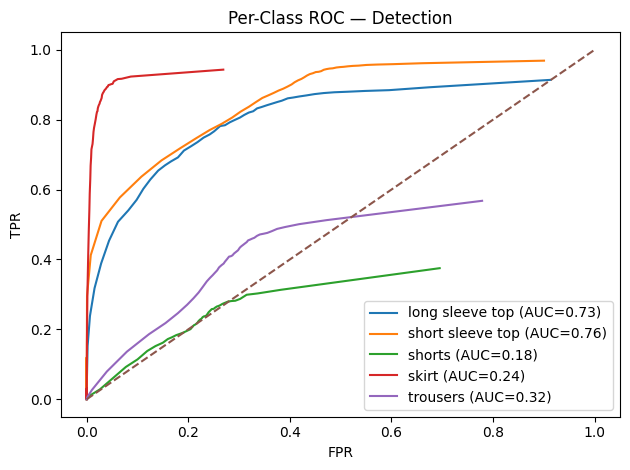

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os, json

# ── Variables needed for ROC ──────────────────────────────────────
iou_threshold = 0.5
thresholds    = np.linspace(0, 1, 50)
class_ids     = list(model_seg.names.keys())   # [0, 1, 2, 3, 4]

# ── Single pass: cache both predictions and GT ────────────────────
cache = []

results_roc = model_seg.predict(
    "/kaggle/working/yolo/seg/val/images",
    save=False,
    conf=0.001,
    stream=True,   # memory safe
)

for result in results_roc:
    img = Image.open(result.path)
    W, H = img.size
    img.close()

    img_name  = os.path.basename(result.path)
    anno_path = os.path.join(ANNO_DIR, img_name.replace(".jpg", ".json"))

    gt_boxes, gt_classes = [], []
    if os.path.exists(anno_path):
        with open(anno_path) as f:
            data = json.load(f)
        for item in data.values():
            if not isinstance(item, dict):
                continue
            cat = item.get("category_name")
            if cat not in class_to_id:
                continue
            bbox = item.get("bounding_box")
            if bbox is None:
                continue
            x1, y1, x2, y2 = bbox
            if x2 <= x1 or y2 <= y1:
                continue
            gt_classes.append(class_to_id[cat])   # 0-indexed, matches model_seg.names
            gt_boxes.append([x1, y1, x2, y2])

    cache.append({
        "pred_boxes":   result.boxes.xyxy.cpu().numpy(),
        "pred_scores":  result.boxes.conf.cpu().numpy(),
        "pred_classes": result.boxes.cls.cpu().numpy(),
        "gt_boxes":     gt_boxes,
        "gt_classes":   gt_classes,
    })

print(f"Cached {len(cache)} images")

# ── Per-class ROC ─────────────────────────────────────────────────
plt.figure()

for cls_id in class_ids:
    all_tpr, all_fpr = [], []

    for thresh in thresholds:
        TP, FP, FN, TN = 0, 0, 0, 0

        for entry in cache:
            pred_boxes   = entry["pred_boxes"]
            pred_scores  = entry["pred_scores"]
            pred_classes = entry["pred_classes"]
            gt_boxes     = entry["gt_boxes"]
            gt_classes   = entry["gt_classes"]

            used_gt = set()

            for p_box, score, p_cls in zip(pred_boxes, pred_scores, pred_classes):
                if score < thresh or int(p_cls) != cls_id:
                    continue
                best_iou, best_gt_idx = 0, -1
                for i, gt in enumerate(gt_boxes):
                    if i in used_gt or gt_classes[i] != cls_id:
                        continue
                    x1 = max(p_box[0], gt[0]); y1 = max(p_box[1], gt[1])
                    x2 = min(p_box[2], gt[2]); y2 = min(p_box[3], gt[3])
                    inter = max(0, x2-x1) * max(0, y2-y1)
                    union = ((p_box[2]-p_box[0])*(p_box[3]-p_box[1]) +
                             (gt[2]-gt[0])*(gt[3]-gt[1]) - inter)
                    iou = inter / (union + 1e-16)
                    if iou > best_iou:
                        best_iou = iou; best_gt_idx = i

                if best_iou >= iou_threshold:
                    TP += 1; used_gt.add(best_gt_idx)
                else:
                    FP += 1

            FN += sum(1 for i in range(len(gt_boxes))
                      if gt_classes[i] == cls_id and i not in used_gt)
            TN += sum(1 for i in range(len(gt_boxes))
                      if gt_classes[i] != cls_id)

        TPR = TP / (TP + FN + 1e-16)
        FPR = FP / (FP + TN + 1e-16)
        all_tpr.append(TPR); all_fpr.append(FPR)

    all_fpr = np.array(all_fpr)
    all_tpr = np.array(all_tpr)
    idx     = np.argsort(all_fpr)
    roc_auc = float(np.trapz(all_tpr[idx], all_fpr[idx]))
    plt.plot(all_fpr[idx], all_tpr[idx],
             label=f"{model_seg.names[cls_id]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Per-Class ROC — Detection")
plt.legend(); plt.tight_layout()
plt.show()

In [20]:
def compute_metrics(y_true, y_pred, num_classes=6):

    iou_list = []
    dice_list = []

    for cls in range(1,num_classes):

        intersection = 0
        union = 0
        pred_area = 0
        gt_area = 0

        for gt, pred in zip(y_true, y_pred):

            gt_mask = (gt == cls)
            pred_mask = (pred == cls)

            intersection += np.logical_and(gt_mask, pred_mask).sum()
            union += np.logical_or(gt_mask, pred_mask).sum()

            pred_area += pred_mask.sum()
            gt_area += gt_mask.sum()

        iou = intersection / (union + 1e-16)
        dice = (2 * intersection) / (pred_area + gt_area + 1e-16)

        iou_list.append(iou)
        dice_list.append(dice)

    return iou_list, dice_list, np.mean(iou_list), np.mean(dice_list)

In [21]:
iou_list, dice_list, mean_iou, mean_dice = compute_metrics(y_true, y_pred)

print("\n" + "="*50)
print("🧵 SEGMENTATION PERFORMANCE")
print("="*50)

for i, cls in enumerate(classes_bg[1:],start=1):
    print(f"{cls:20} | IoU: {iou_list[i-1]:.4f} | Dice(F1): {dice_list[i-1]:.4f}")

print("\n" + "-"*50)
print(f"Mean IoU (mIoU): {mean_iou:.4f}")
print(f"Mean Dice (F1):  {mean_dice:.4f}")


🧵 SEGMENTATION PERFORMANCE
long sleeve top      | IoU: 0.5592 | Dice(F1): 0.7173
short sleeve top     | IoU: 0.6877 | Dice(F1): 0.8150
shorts               | IoU: 0.6729 | Dice(F1): 0.8045
skirt                | IoU: 0.6315 | Dice(F1): 0.7742
trousers             | IoU: 0.6753 | Dice(F1): 0.8062

--------------------------------------------------
Mean IoU (mIoU): 0.6453
Mean Dice (F1):  0.7834
